In [1]:
import JupyterNotebooksLib as slicernb

# Install geomdl - NURBS modeling package
try:
    import geomdl
except:
    pip_install('geomdl')

In [2]:
# source: http://stackoverflow.com/questions/12299540/plane-fitting-to-4-or-more-xyz-points
def planeFit(points):
  """
  p, n = planeFit(points)

  Given an array, points, of shape (d,...)
  representing points in d-dimensional space,
  fit an d-dimensional plane to the points.
  Return a point, p, on the plane (the point-cloud centroid),
  and the normal, n.
  """
  import numpy as np
  from numpy.linalg import svd
  points = np.reshape(points, (np.shape(points)[0], -1)) # Collapse trialing dimensions
  assert points.shape[0] <= points.shape[1], "There are only {} points in {} dimensions.".format(points.shape[1],
                                                                                                 points.shape[0])
  ctr = points.mean(axis=1)
  x = points - ctr[:,np.newaxis]
  M = np.dot(x, x.T) # Could also use np.cov(x) here.
  return ctr, svd(M)[0][:,-1] 

In [3]:
def getTransformToPlane(planePosition, planeNormal, xDirection=None):
  """Returns transform matrix from World to Plane coordinate systems.
  Plane is defined in the World coordinate system by planePosition and planeNormal.
  Plane coordinate system: origin is planePosition, z axis is planeNormal, x and y axes are orthogonal to z.
  """
  import numpy as np
  import math

  # Determine the plane coordinate system axes.
  planeZ_World = planeNormal/np.linalg.norm(planeNormal)

  # Generate a plane Y axis by generating an orthogonal vector to
  # plane Z axis vector by cross product plane Z axis vector with
  # an arbitrarily chosen vector (that is not parallel to the plane Z axis).
  if xDirection:
    unitX_World = np.array(xDirection)
    unitX_World = unitX_World/np.linalg.norm(unitX_World)
  else:
    unitX_World = np.array([0,0,1])
  angle = math.acos(np.dot(planeZ_World,unitX_World))
  # Normalize between -pi/2 .. +pi/2
  if angle>math.pi/2:
    angle -= math.pi
  elif angle<-math.pi/2:
    angle += math.pi
  if abs(angle)*180.0/math.pi>20.0:
    # unitX is not parallel to planeZ, we can use it
    planeY_World = np.cross(planeZ_World, unitX_World)
  else:
    # unitX is parallel to planeZ, use unitY instead
    unitY_World = np.array([0,1,0])
    planeY_World = np.cross(planeZ_World, unitY_World)

  planeY_World = planeY_World/np.linalg.norm(planeY_World)

  # X axis: orthogonal to tool's Y axis and Z axis
  planeX_World = np.cross(planeY_World, planeZ_World)
  planeX_World = planeX_World/np.linalg.norm(planeX_World)

  transformPlaneToWorld = np.row_stack((np.column_stack((planeX_World, planeY_World, planeZ_World, planePosition)),
                                        (0, 0, 0, 1)))
  transformWorldToPlane = np.linalg.inv(transformPlaneToWorld)

  return transformWorldToPlane

def getVtkTransformPlaneToWorld(planePosition, planeNormal, xDirection=None):
  import numpy as np
  transformPlaneToWorldVtk = vtk.vtkTransform()
  transformWorldToPlaneMatrix = getTransformToPlane(planePosition, planeNormal, xDirection)
  transformPlaneToWorldMatrix = np.linalg.inv(transformWorldToPlaneMatrix)
  transformWorldToPlaneMatrixVtk = slicer.util.vtkMatrixFromArray(transformPlaneToWorldMatrix)
  transformPlaneToWorldVtk.SetMatrix(transformWorldToPlaneMatrixVtk)
  return transformPlaneToWorldVtk 

In [4]:
def getPointsOnPlane(polyData, planePosition, planeNormal):
    plane = vtk.vtkPlane()
    plane.SetOrigin(planePosition)
    plane.SetNormal(planeNormal)
    cutEdges = vtk.vtkCutter()
    cutEdges.SetInputData(polyData)
    cutEdges.SetCutFunction(plane)
    cutEdges.GenerateCutScalarsOff()
    cutEdges.SetValue(0, 0)
    #cutEdges.Update()
    
    mergeLines = vtk.vtkStripper()
    mergeLines.SetInputConnection(cutEdges.GetOutputPort())
    mergeLines.Update()
    intersection = mergeLines.GetOutput()
    intersectionPoints = intersection.GetPoints()
    n = intersectionPoints.GetNumberOfPoints()
    import numpy as np
    points = np.zeros([3,n])
    pos = [0.0, 0.0, 0.0]
    for i in range(n):
        intersectionPoints.GetPoint(i, pos)
        points[:,i] = pos
    return points

def createTransformToWorldXYPlane(surfaceModelNode, xDirection=None):
    # Create transform node that transforms the surface model to the XY plane (in world coordinate system)
    medialSurfaceNodePoints = slicer.util.arrayFromModelPoints(surfaceModelNode)
    [planePosition, planeNormal] = planeFit(medialSurfaceNodePoints.T)
    transformToPlane = getVtkTransformPlaneToWorld(planePosition, planeNormal, xDirection=xDirection)
    modelToXYPlaneTransformNode = slicer.mrmlScene.AddNewNodeByClass("vtkMRMLTransformNode")
    modelToXYPlaneTransformNode.SetAndObserveTransformFromParent(transformToPlane)
    return modelToXYPlaneTransformNode

In [5]:
def fitNurbsSurfaceToModel(medialSurfaceNode, size_u = 8, size_v = 8, degree_u = 2, degree_v = 2, resolution=0.05, trim_curve=None, xDirection=None):
    # Transform medial surface to XY plane for easier computation
    leafletToXYPlaneTransformNode = createTransformToWorldXYPlane(medialSurfaceNode, xDirection=xDirection)
    medialSurfaceNode.SetAndObserveTransformNodeID(leafletToXYPlaneTransformNode.GetID())
    medialSurfaceNode.HardenTransform()

    # Create points array that the NURBS will fit to by cutting the leaflet with XZ planes
    import numpy as np
    bounds=np.zeros(6)
    medialSurfaceNode.GetBounds(bounds)
    margin = (bounds[1]-bounds[0])*0.05  # margin so that cut planes go through the surface and not just touching the side
    import math
    points = []
    for uindex in range(size_u):
        intersectionPoints = getPointsOnPlane(medialSurfaceNode.GetPolyData(), [bounds[0]+margin+(bounds[1]-bounds[0]-2*margin)*uindex/(size_u-1),0,0], [1,0,0])
        # Sort based on y coordinates
        intersectionPoints = intersectionPoints[:,intersectionPoints[1,:].argsort()]
        numberOfIntersectionPoints = intersectionPoints.shape[1]
        if numberOfIntersectionPoints <= 1:
            raise ValueError("No intersection found with model")
        sampleIndices = (np.arange(size_v) * (numberOfIntersectionPoints-1) / (size_v-1)).astype(int)
        sampledPoints = list(intersectionPoints[:,sampleIndices].T)
        points.extend(sampledPoints)
        
    # Do global surface interpolation
    from geomdl import fitting
    from geomdl import tessellate
    from geomdl import exchange_vtk
    surf = fitting.interpolate_surface(points, size_u, size_v, degree_u, degree_v)

    # Plot the interpolated surface
    surf.delta = resolution

#     if trim_curve:
#         # Generate a trim curve
#         print("trimming")
#         from geomdl import BSpline
#         from geomdl import knotvector
#         tcrv = BSpline.Curve()
#         tcrv.degree = 1
#         tcrv.ctrlpts = [[0.2, 0.2], [0.8, 0.4], [0.7, 0.9], [0.2, 0.9]]
#         tcrv.opt = ['reversed', 1]
#         tcrv.knotvector = knotvector.generate(tcrv.degree, len(tcrv.ctrlpts))
#         trim_curves = [tcrv]

#         # Set trim curves (as a list)
#         surf.trims = trim_curves
#         surf.tessellator = tessellate.TrimTessellate()
        
    #surf.tessellator = tessellate.QuadTessellate()

    exchange_vtk.export_polydata(surf, "_temp_surf.vtk", tessellate=True)
    #exchange_vtk.export_polydata(surf, "surf.vtk", point_type="ctrlpts", tessellate=False)

    tessellatedModelNode = slicer.util.loadNodeFromFile(slicernb.localPath('_temp_surf.vtk'), 'ModelFile', {"coordinateSystem": "RAS"})
    tessellatedModelNode.SetName(medialSurfaceNode.GetName()+'-fit')
    
    # Transform back to original position
    tessellatedModelNode.SetAndObserveTransformNodeID(leafletToXYPlaneTransformNode.GetID())
    medialSurfaceNode.SetAndObserveTransformNodeID(leafletToXYPlaneTransformNode.GetID())
    leafletToXYPlaneTransformNode.Inverse()
    tessellatedModelNode.HardenTransform()
    medialSurfaceNode.HardenTransform()
    slicer.mrmlScene.RemoveNode(leafletToXYPlaneTransformNode)

    return tessellatedModelNode

In [6]:
anteriorModelNode = slicer.util.loadModel(r'c:\Users\andra\OneDrive\Projects\SlicerHeart\20200616-FEBio-model\Data\mitral\anterior-voronoi.ply')
posteriorModelNode = slicer.util.loadModel(r'c:\Users\andra\OneDrive\Projects\SlicerHeart\20200616-FEBio-model\Data\mitral\posterior-voronoi.ply')

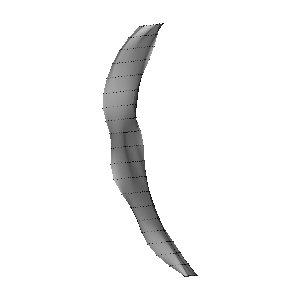

In [7]:
xDirection = [0,1,0]
fitNurbsSurfaceToModel(anteriorModelNode, xDirection=xDirection)
fitNurbsSurfaceToModel(posteriorModelNode, xDirection=xDirection)

In [8]:
#slicernb.AppWindow().setContents("viewers")
slicernb.AppWindow().setContents("full")

slicer.modules.jupyterkernel.setPollIntervalSec(0.001)

slicernb.ViewDisplay("OneUp3D", center=False)  # You can also try: FourUp, OneUpRedSlice, OneUp3D

# 3D view
slicernb.AppWindow.setWindowSize(scale=0.2)
live3d = slicernb.ViewInteractiveWidget('1')
live3d.trackMouseMove = True
display(live3d)

ViewInteractiveWidget(height=624, width=1020)